# Chest Health Classification
**Final Project - Medical Image Processing & Deep Learning**

* **Composers:**
Ronen Milikov, 322883224
| Shachar Wilk, 214149759

### Project Description
Development of a deep learning model based on convolutional networks (CNN) to classify chest X-rays into 4 diagnostic categories: COVID-19, Viral Pneumonia, Lung Opacity, and Normal.

# Note: Training this model on a standard CPU will take a significant amount of time.
# Please ensure a GPU (e.g., T4 in Google Colab) is allocated before running model.fit()

### 1. Setup and Library Imports
Importing the necessary library to interface with Kaggle datasets and other libraries.

In [ ]:
import kagglehub
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("Libraries imported successfully!")

Libraries imported successfully!


### 2. Download Dataset
Downloading the COVID-19 Radiography Database from Kaggle using `kagglehub`.

In [ ]:
print("Downloading dataset...")
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.


### 3. Verify Local Path
Printing the local directory path where the dataset has been stored.

In [ ]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/covid19-radiography-database


### 4. Visualize Sample Images from Each Class
Loading and displaying one representative X-ray image from each of the four categories: COVID, Normal, Viral Pneumonia, and Lung Opacity.

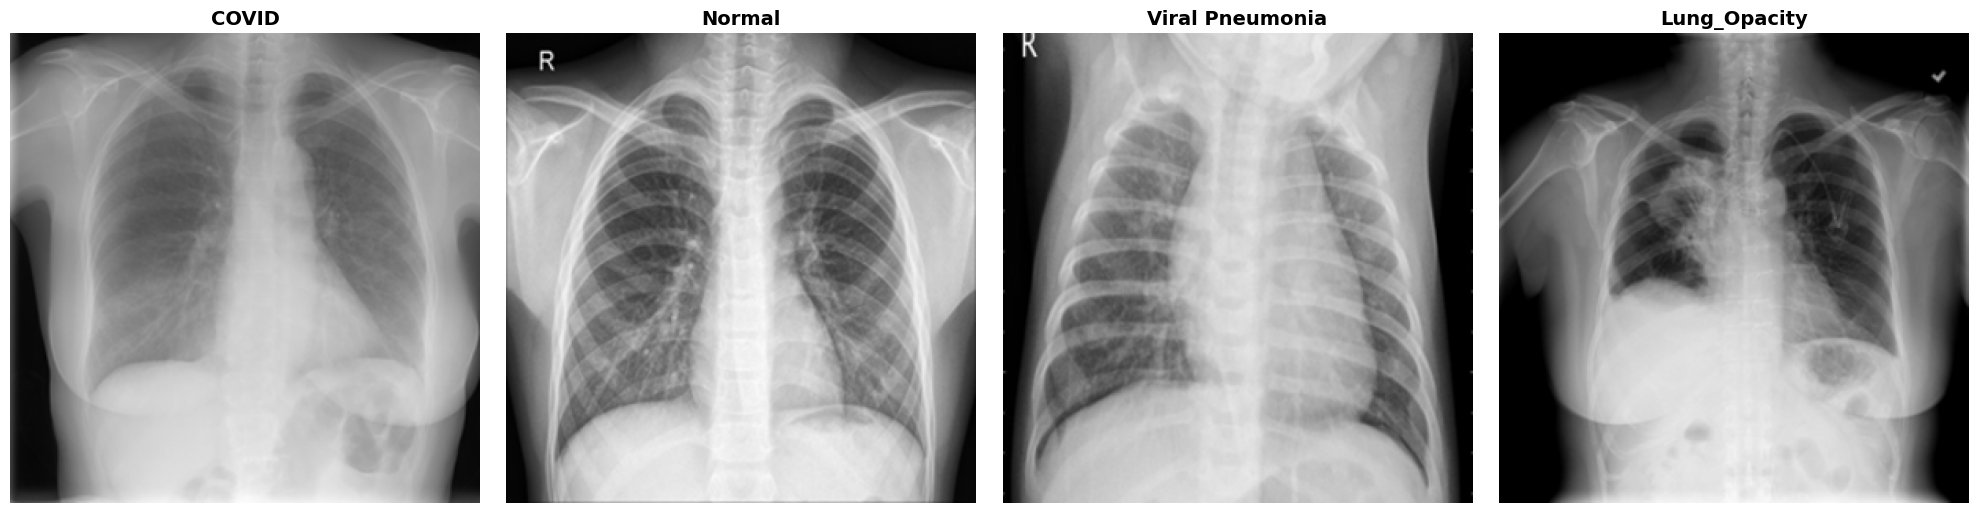

In [ ]:
# The path to the main directory
base_dir = os.path.join(path, "COVID-19_Radiography_Dataset")

# Updated class names to match the actual directory names
classes = ['COVID', 'Normal', 'Viral Pneumonia', 'Lung_Opacity']

# Prepare canvas for 4 images
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, class_name in enumerate(classes):
    # Access the 'images' subdirectory within each class folder
    class_dir = os.path.join(base_dir, class_name, "images")

    # Get the first image file name
    if os.path.exists(class_dir):
        files = os.listdir(class_dir)
        if files:
            first_image_name = files[0]
            img_path = os.path.join(class_dir, first_image_name)

            # Read and convert image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Display
            axes[i].imshow(img)
            axes[i].set_title(class_name, fontsize=14, fontweight='bold')
    else:
        print(f"Warning: Directory not found: {class_dir}")

    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 5. Define the CNN Model Architecture
In this section, we define the Convolutional Neural Network (CNN) architecture using Transfer Learning.
The model is designed to map the 2D X-ray inputs to our 4 diagnostic categories using the following steps:
* **Rescaling:** Normalizing pixel values to the [0, 1] range to optimize learning.
* **Feature Extraction (Transfer Learning):** Utilizing the robust, pre-trained ResNet50 architecture (with frozen weights) to automatically extract complex visual patterns from the X-rays.
* **Global Pooling & Classification:** Using GlobalAveragePooling2D followed by fully-connected Dense layers and Dropout to prevent overfitting, outputting the final probability for each of the 4 medical classes.

In [ ]:
# Setting the size the images will be resized to before entering the network
img_height = 224
img_width = 224
num_classes = 4 # COVID, Normal, Viral Pneumonia, Lung Opacity

# Load the pre-trained ResNet50 model (without the original classification head)
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',  # Load weights pre-trained on ImageNet
    input_shape=(img_height, img_width, 3),
    include_top=False    # Do not include the original 1000-class ImageNet classifier
)

base_model.trainable = True

# Create a new model on top
model = models.Sequential([
    # Step 1: Normalizing pixels from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # Step 2: The pre-trained ResNet50 feature extractor
    base_model,

    # Step 3: Global Average Pooling (Recommended over Flatten for ResNet)
    layers.GlobalAveragePooling2D(),

    # Step 4: Fully Connected Layers for our specific medical task
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Adding Dropout to prevent overfitting
    layers.Dense(num_classes)
])

print("ResNet50 Transfer Learning Architecture successfully defined!")

# Displaying the model architecture summary
model.summary()

ResNet50 Transfer Learning Architecture successfully defined!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 23,797,380 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

### 6. Data Loading and Splitting
In this step, we load the images from their respective directories and split them into training and validation sets using an 80/20 ratio.
*   **Data Partitioning:** 80% of the data is used for training the model, while 20% is reserved for validation to evaluate the model's performance on unseen data.
*   **Performance Optimization:** We utilize `prefetch` to allow the CPU to prepare the next batch of images while the GPU is processing the current one, significantly accelerating training without exhausting the system's RAM.

In [ ]:
# Define batch size
batch_size = 32

print("Loading training data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

print("Loading validation data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Performance optimization: prefetch data to speed up training WITHOUT crashing the RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Loading training data...
Found 42330 files belonging to 4 classes.
Using 33864 files for training.
Loading validation data...
Found 42330 files belonging to 4 classes.
Using 8466 files for validation.


### 7. Calculating Class Weights
The `scikit-learn` library can automatically calculate the exact weight ratio for each class to balance the dataset. This forces the model to give more importance to minority classes (like COVID) during training and reduces false positive errors.

In [ ]:
import os
import numpy as np

print("Calculating class weights directly from directory counts...")

classes = ['COVID', 'Normal', 'Viral Pneumonia', 'Lung_Opacity']
class_counts = []

for class_name in classes:
    class_dir = os.path.join(base_dir, class_name, "images")

    num_images = len(os.listdir(class_dir))
    class_counts.append(num_images)

class_counts = np.array(class_counts)
total_images = np.sum(class_counts)
num_classes = len(classes)

class_weights_array = total_images / (num_classes * class_counts)

class_weights_dict = dict(enumerate(class_weights_array))

print("Class Counts:", class_counts)
print("Class Weights Dictionary:")
print(class_weights_dict)

Calculating class weights directly from directory counts...
Class Counts: [ 3616 10192  1345  6012]
Class Weights Dictionary:
{0: np.float64(1.4632881637168142), 1: np.float64(0.5191571821036107), 2: np.float64(3.934014869888476), 3: np.float64(0.8801147704590818)}


### 8. Compile and Train the Model
This stage executes the actual training process:
*   **Compilation:** We configure the training engine using the `Adam` optimizer, which is a standard choice for efficient and stable convergence, and `SparseCategoricalCrossentropy` as the loss function, suitable for multi-class classification tasks.
*   **Training:** The model iterates through the training data for 10 epochs. In each epoch, the model updates its weights to minimize loss and improves its accuracy. At the end of each epoch, it is evaluated against the validation set to monitor for overfitting and ensure effective generalization.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

epochs = 10

print("Starting model training...")
history = model.fit(
    x=train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights_dict
)
print("Training completed!")

Starting model training...
Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 468s 382ms/step - accuracy: 0.6540 - loss: 0.9547 - val_accuracy: 0.5862 - val_loss: 1.2903
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 370s 349ms/step - accuracy: 0.7261 - loss: 0.7574 - val_accuracy: 0.6538 - val_loss: 0.8710
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 369s 349ms/step - accuracy: 0.7434 - loss: 0.7138 - val_accuracy: 0.7712 - val_loss: 0.5808
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 369s 349ms/step - accuracy: 0.7677 - loss: 0.6508 - val_accuracy: 0.7522 - val_loss: 0.6757
Epoch 5/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 369s 349ms/step - accuracy: 0.7776 - loss: 0.6181 - val_accuracy: 0.7573 - val_loss: 0.6223
Epoch 6/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 370s 349ms/step - accuracy: 0.7882 - loss: 0.5979 - val_accuracy: 0.7189 - val_loss: 0.6833
Epoch 7/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 370s 349ms/step - accuracy: 0.7950 - loss: 0.5722 - val_accuracy: 0.7543 - val_loss: 0.6705
Epoch 8/10
1059/1059 ━━━━━━━━━━━━━━

### 9. Plot Training History
After the training process concludes, we visualize the model's learning progress by plotting the accuracy and loss curves over the 10 epochs.
*   **Purpose:** These plots are essential for evaluating the model's convergence and identifying potential issues like overfitting (if training accuracy significantly outperforms validation accuracy) or underfitting.


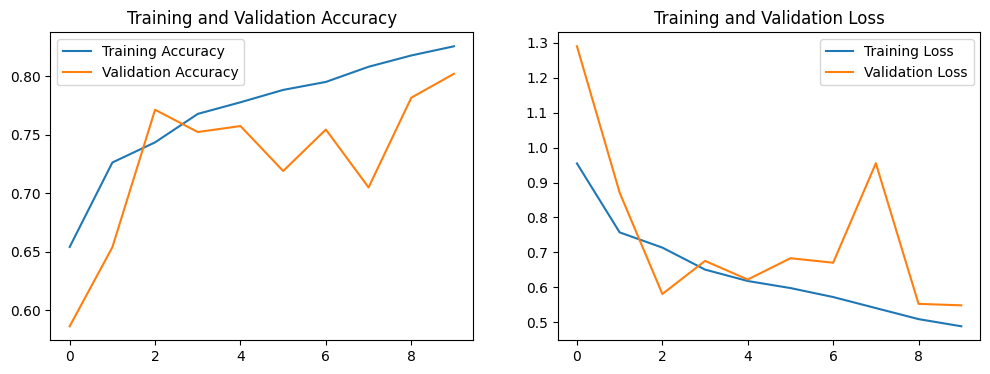

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### 10. Confusion Matrix and Classification Report
To provide a comprehensive performance analysis, we generate a confusion matrix and a detailed classification report on the validation set.
*   **Confusion Matrix:** A heatmap that visualizes the model's ability to distinguish between the four diagnostic classes (COVID-19, Normal, Viral Pneumonia, and Lung Opacity). This allows us to identify which classes are most frequently misclassified.
*   **Classification Report:** Provides critical quantitative metrics, including precision, recall, and F1-score for each class, giving us a deeper understanding of the model's diagnostic reliability.

Generating predictions batch-by-batch to maintain exact synchronization...


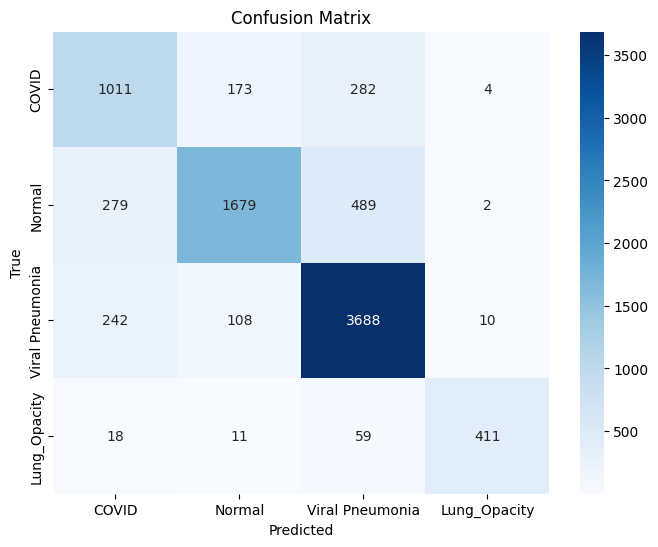

                 precision    recall  f1-score   support

          COVID       0.65      0.69      0.67      1470
         Normal       0.85      0.69      0.76      2449
Viral Pneumonia       0.82      0.91      0.86      4048
   Lung_Opacity       0.96      0.82      0.89       499

       accuracy                           0.80      8466
      macro avg       0.82      0.78      0.79      8466
   weighted avg       0.81      0.80      0.80      8466



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("Generating predictions batch-by-batch to maintain exact synchronization...")

y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.append(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.append(preds)

y_true = np.concatenate(y_true, axis=0)
y_pred_probs = np.concatenate(y_pred_probs, axis=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=classes))

### 11. ROC Curve Visualization
To further assess the model's diagnostic capability, we generate a Receiver Operating Characteristic (ROC) curve for each class using a one-vs-rest approach.
*   **Purpose:** The ROC curve illustrates the diagnostic ability of our multi-class classifier as its discrimination threshold is varied. The Area Under the Curve (AUC) provides a quantitative measure of performance; an AUC of 1.0 represents a perfect model, while 0.5 indicates random guessing.
*   **Evaluation:** This metric allows us to evaluate the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate (1-Specificity) for each lung condition.

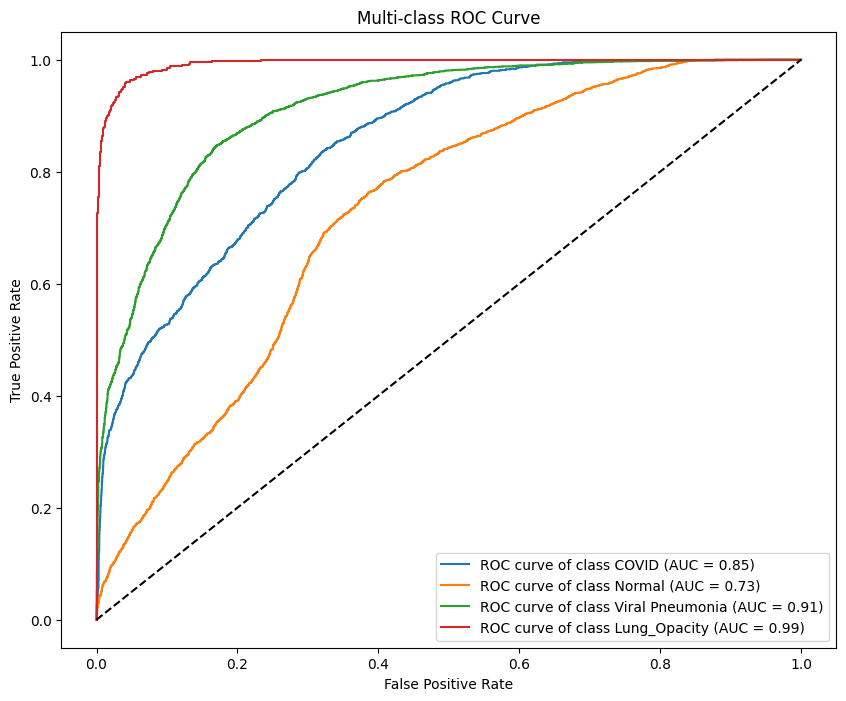

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
n_classes = 4

# Compute ROC curve and ROC area for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve of class {classes[i]} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save('medical_chest_classifier.keras')